In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta
import os

tickers = ["AMD", "AAPL", "MSFT", "GOOGL", "META", "NVDA", "ABNB", "TSLA", "AMZN", "NFLX"]
os.makedirs("data/features", exist_ok=True)

In [6]:
def add_features(ticker):
    # 读取原始数据（不是归一化的，技术指标要用真实价格算）
    df = pd.read_csv(f"data/raw/{ticker}_price.csv", header=[0,1], index_col=0)
    df.index = pd.to_datetime(df.index)
    df.columns = df.columns.get_level_values(0)
    df = df.dropna().sort_index()

    close = df["Close"]
    high = df["High"]
    low = df["Low"]
    volume = df["Volume"]

    # SMA / EMA
    df["SMA_20"] = ta.trend.sma_indicator(close, window=20)
    df["SMA_50"] = ta.trend.sma_indicator(close, window=50)
    df["EMA_20"] = ta.trend.ema_indicator(close, window=20)

    # RSI
    df["RSI_14"] = ta.momentum.rsi(close, window=14)

    # MACD
    macd = ta.trend.MACD(close)
    df["MACD"] = macd.macd()
    df["MACD_signal"] = macd.macd_signal()
    df["MACD_diff"] = macd.macd_diff()

    # Bollinger Bands
    bb = ta.volatility.BollingerBands(close, window=20)
    df["BB_upper"] = bb.bollinger_hband()
    df["BB_lower"] = bb.bollinger_lband()
    df["BB_width"] = bb.bollinger_wband()

    # 滚动波动率（20日）
    df["Volatility_20"] = close.pct_change().rolling(20).std()

    # Lag features（前1、3、5日收益率）
    df["Return_1d"] = close.pct_change(1)
    df["Return_3d"] = close.pct_change(3)
    df["Return_5d"] = close.pct_change(5)

    # 目标变量：明日涨跌方向（1=涨，0=跌）
    df["Target"] = (close.shift(-1) > close).astype(int)

    # 删除指标计算产生的空行
    df = df.dropna()

    df.to_csv(f"data/features/{ticker}_features.csv")
    print(f"{ticker}: {len(df)} 行，{len(df.columns)} 列特征")
    return df

# 对所有股票计算
for ticker in tickers:
    add_features(ticker)

AMD: 1460 行，20 列特征
AAPL: 1460 行，20 列特征
MSFT: 1460 行，20 列特征
GOOGL: 1460 行，20 列特征
META: 1460 行，20 列特征
NVDA: 1460 行，20 列特征
ABNB: 970 行，20 列特征
TSLA: 1460 行，20 列特征
AMZN: 1460 行，20 列特征
NFLX: 1460 行，20 列特征


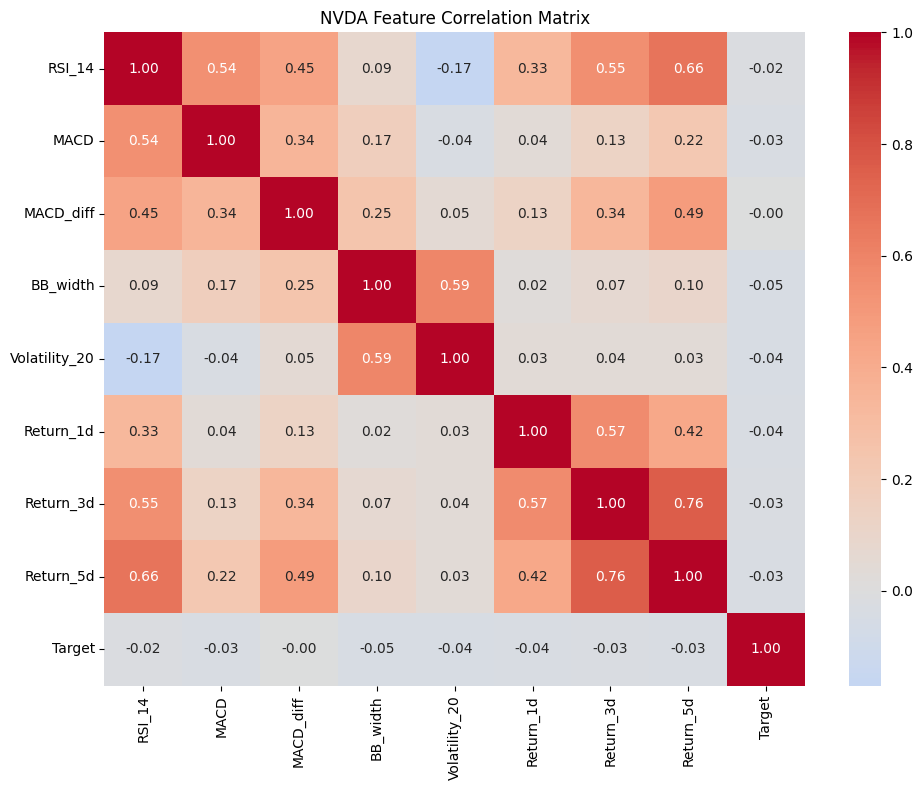

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 用 NVDA 做示例
df = pd.read_csv("data/features/NVDA_features.csv", index_col=0)

feature_cols = ["RSI_14", "MACD", "MACD_diff", "BB_width", 
                "Volatility_20", "Return_1d", "Return_3d", "Return_5d", "Target"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NVDA Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("data/features/NVDA_correlation.png", dpi=150)
plt.show()

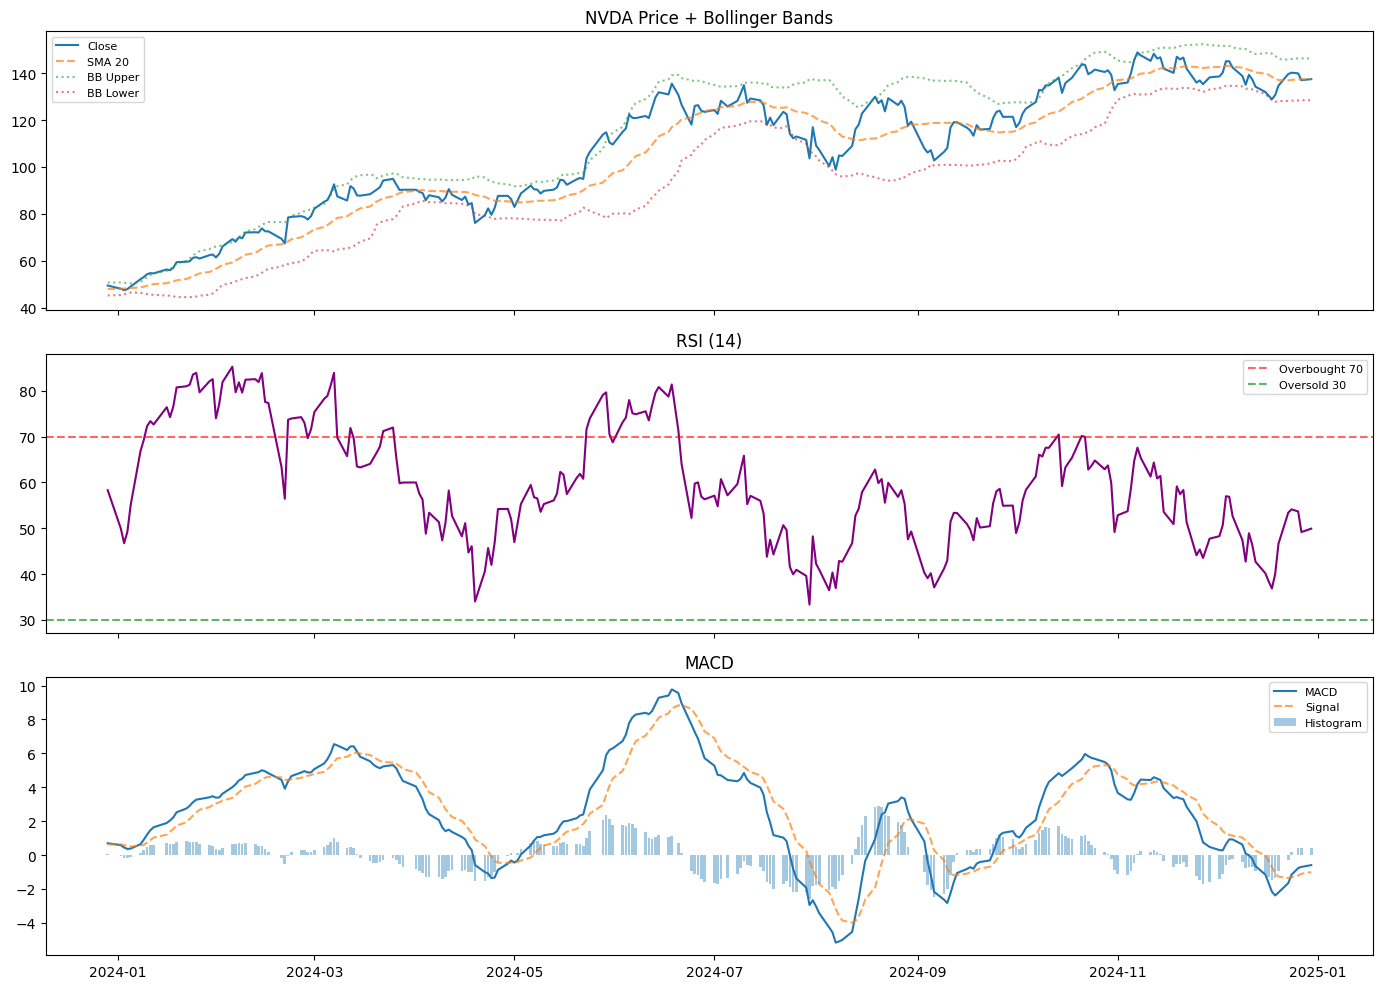

In [8]:
df = pd.read_csv("data/features/NVDA_features.csv", index_col=0, parse_dates=True)
df_plot = df.tail(252)  # 最近一年

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 价格 + 布林带 + SMA
axes[0].plot(df_plot.index, df_plot["Close"], label="Close", linewidth=1.5)
axes[0].plot(df_plot.index, df_plot["SMA_20"], label="SMA 20", linestyle="--", alpha=0.7)
axes[0].plot(df_plot.index, df_plot["BB_upper"], label="BB Upper", linestyle=":", alpha=0.6)
axes[0].plot(df_plot.index, df_plot["BB_lower"], label="BB Lower", linestyle=":", alpha=0.6)
axes[0].set_title("NVDA Price + Bollinger Bands")
axes[0].legend(fontsize=8)

# RSI
axes[1].plot(df_plot.index, df_plot["RSI_14"], color="purple", linewidth=1.5)
axes[1].axhline(70, color="red", linestyle="--", alpha=0.6, label="Overbought 70")
axes[1].axhline(30, color="green", linestyle="--", alpha=0.6, label="Oversold 30")
axes[1].set_title("RSI (14)")
axes[1].legend(fontsize=8)

# MACD
axes[2].plot(df_plot.index, df_plot["MACD"], label="MACD", linewidth=1.5)
axes[2].plot(df_plot.index, df_plot["MACD_signal"], label="Signal", linestyle="--", alpha=0.7)
axes[2].bar(df_plot.index, df_plot["MACD_diff"], label="Histogram", alpha=0.4)
axes[2].set_title("MACD")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("data/features/NVDA_indicators.png", dpi=150)
plt.show()

In [9]:
print("=== Week 3 特征工程报告 ===")
for ticker in tickers:
    df = pd.read_csv(f"data/features/{ticker}_features.csv", index_col=0)
    print(f"{ticker}: {len(df)} 行, {len(df.columns)} 列, Target分布: {df['Target'].value_counts().to_dict()}")

=== Week 3 特征工程报告 ===
AMD: 1460 行, 20 列, Target分布: {1: 732, 0: 728}
AAPL: 1460 行, 20 列, Target分布: {1: 785, 0: 675}
MSFT: 1460 行, 20 列, Target分布: {1: 785, 0: 675}
GOOGL: 1460 行, 20 列, Target分布: {1: 793, 0: 667}
META: 1460 行, 20 列, Target分布: {1: 760, 0: 700}
NVDA: 1460 行, 20 列, Target分布: {1: 794, 0: 666}
ABNB: 970 行, 20 列, Target分布: {1: 487, 0: 483}
TSLA: 1460 行, 20 列, Target分布: {1: 773, 0: 687}
AMZN: 1460 行, 20 列, Target分布: {1: 762, 0: 698}
NFLX: 1460 行, 20 列, Target分布: {1: 750, 0: 710}
